In [1]:
import kagglehub
from pathlib import Path
from fastcore.all import *
from fastai.vision.all import *

## Download preprocessed dataset

In [2]:
resized_dataset_path = kagglehub.dataset_download('aviramsiginur/resized-dataset')
resized_dataset_path

'/kaggle/input/datasets/aviramsiginur/resized-dataset'

In [3]:
failed = verify_images(get_image_files(resized_dataset_path))
len(failed)

0

## Create a DataBlock
- For now I'm using the squishing method.

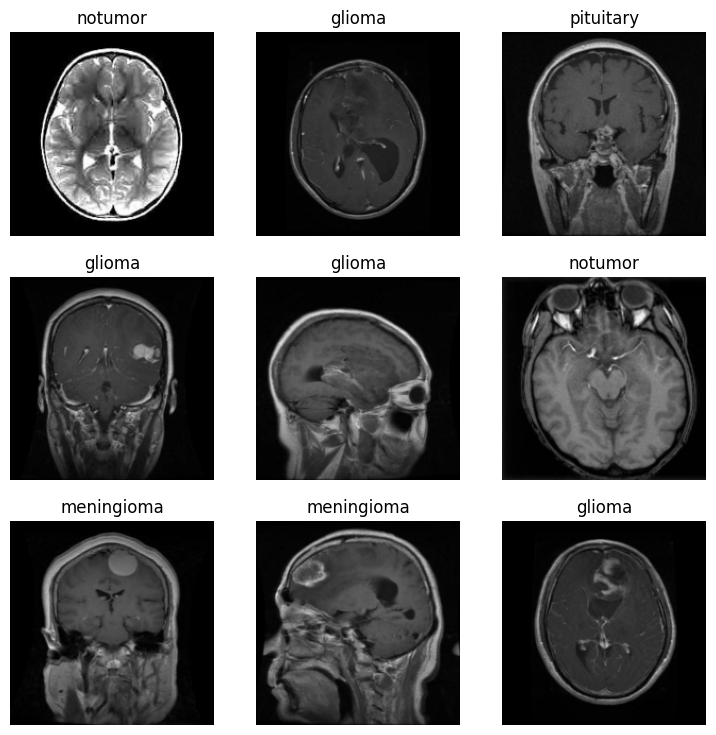

In [4]:
set_seed(42, reproducible=True)
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=GrandparentSplitter(train_name='Training', valid_name='Testing'),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(resized_dataset_path)

dls.show_batch(max_n=9)

## Train a ResNet18 model

In [5]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(2)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 153MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,0.727652,0.579036,0.148125,00:17


epoch,train_loss,valid_loss,error_rate,time
0,0.287394,0.425723,0.088125,00:17
1,0.108980,0.385150,0.073125,00:17


> In the 3rd epoch, both the validation loss and error_rate raised a bit, which probably means that the model is overfitted, so I decided to change the number of epochs to 2.

## Predict tumor type in a downloaded MRI scan

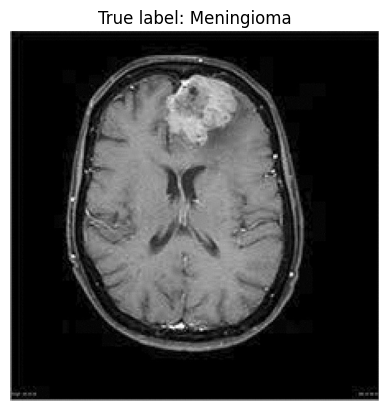

In [6]:
from fastdownload import download_url
import cv2
import matplotlib.pyplot as plt

# Download a meningioma tumor MRI scan from a Nature article
tumor_url = 'https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41598-023-41576-6/MediaObjects/41598_2023_41576_Fig1_HTML.jpg'
destination = 'meningioma_tumor.jpg'
download_url(tumor_url, destination, show_progress=False)

# Show the MRI scan
downloaded_scan = cv2.imread(destination)
plt.imshow(downloaded_scan)
plt.title('True label: Meningioma')
plt.axis('off')
plt.show()

In [7]:
prediction, pred_idx, probs = learn.predict('meningioma_tumor.jpg')
print(f'Prediction: This is a brain with {prediction}')
print(f'Probability it\'s a brain with {prediction}: {probs[pred_idx]:.3f}')

Prediction: This is a brain with meningioma
Probability it's a brain with meningioma: 0.995


## Data augmentation